DATA AUDIT


In [1]:
import pandas as pd
import numpy as np
 
df = pd.read_csv("data/alberta_projects.csv")
 
print("=== SHAPE ===")
print(df.shape)
 
print("\n=== DATA TYPES ===")
print(df.dtypes)
 
print("\n=== MISSING VALUES (count) ===")
missing = df.isnull().sum()
print(missing)
 
print("\n=== MISSING VALUES (%) ===")
print(round(missing / len(df) * 100, 2))
 
print("\n=== DUPLICATE ROWS ===")
print(f"Duplicate rows found: {df.duplicated().sum()}")
 
print("\n=== 'approved' column unique values ===")
print(df["approved"].value_counts(dropna=False))
 
print("\n=== 'status' column unique values ===")
print(df["status"].value_counts(dropna=False))
 
print("\n=== NUMERIC SUMMARY ===")
print(df.describe())

=== SHAPE ===
(210, 15)

=== DATA TYPES ===
project_id               str
project_name             str
city                     str
province                 str
sector                   str
contractor               str
project_value_cad    float64
start_date               str
end_date                 str
status                   str
workers_on_site      float64
safety_incidents     float64
delay_days           float64
inspector_name           str
approved                 str
dtype: object

=== MISSING VALUES (count) ===
project_id            0
project_name          0
city                  0
province              0
sector                0
contractor            0
project_value_cad    11
start_date            0
end_date             18
status                0
workers_on_site      23
safety_incidents     11
delay_days           12
inspector_name       49
approved             27
dtype: int64

=== MISSING VALUES (%) ===
project_id            0.00
project_name          0.00
city                

CLEANING PIPELINE

In [2]:
# --- Remove Duplicates ---
rows_before = len(df)
df = df.drop_duplicates(keep="first").reset_index(drop=True)
print(f"Duplicates removed: {rows_before - len(df)}")
 
# --- Fix Data Types ---
df["start_date"] = pd.to_datetime(df["start_date"], errors="coerce")
df["end_date"]   = pd.to_datetime(df["end_date"],   errors="coerce")
df["project_value_cad"] = pd.to_numeric(df["project_value_cad"], errors="coerce")
 
# --- Standardise approved column ---
df["approved"] = df["approved"].str.strip().str.upper()
approved_map = {"YES": "Yes", "Y": "Yes", "NO": "No", "N": "No"}
df["approved"] = df["approved"].map(approved_map)
 
# --- Standardise status column ---
df["status"] = df["status"].str.strip().str.title()
 
# --- Handle Missing Values ---
median_workers = df["workers_on_site"].median()
df["workers_on_site"] = df["workers_on_site"].fillna(median_workers)
print(f"workers_on_site filled with median: {median_workers}")
 
df["safety_incidents"] = df["safety_incidents"].fillna(0)
 
rows_before = len(df)
df = df.dropna(subset=["project_value_cad"])
print(f"Rows dropped due to missing project_value_cad: {rows_before - len(df)}")
 
# --- Post-Clean Audit ---
print("\n=== POST-CLEAN AUDIT ===")
print(f"Final shape: {df.shape}")
print(f"Remaining nulls:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print("\nData types after cleaning:")
print(df.dtypes)
 
# --- Save Clean Data ---
df.to_csv("data/alberta_projects_clean.csv", index=False)
print("\n✓ Clean data saved to data/alberta_projects_clean.csv")

Duplicates removed: 10
workers_on_site filled with median: 127.5
Rows dropped due to missing project_value_cad: 11

=== POST-CLEAN AUDIT ===
Final shape: (189, 15)
Remaining nulls:
end_date          18
delay_days        11
inspector_name    44
approved          23
dtype: int64

Data types after cleaning:
project_id                      str
project_name                    str
city                            str
province                        str
sector                          str
contractor                      str
project_value_cad           float64
start_date           datetime64[us]
end_date             datetime64[us]
status                          str
workers_on_site             float64
safety_incidents            float64
delay_days                  float64
inspector_name                  str
approved                        str
dtype: object

✓ Clean data saved to data/alberta_projects_clean.csv


VISUALISATION

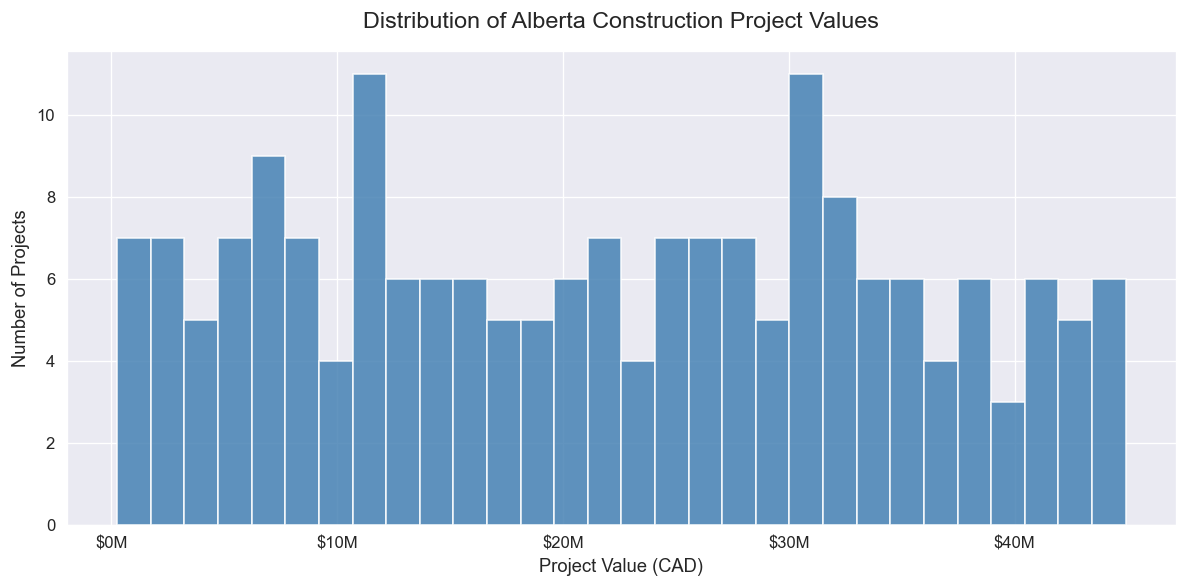

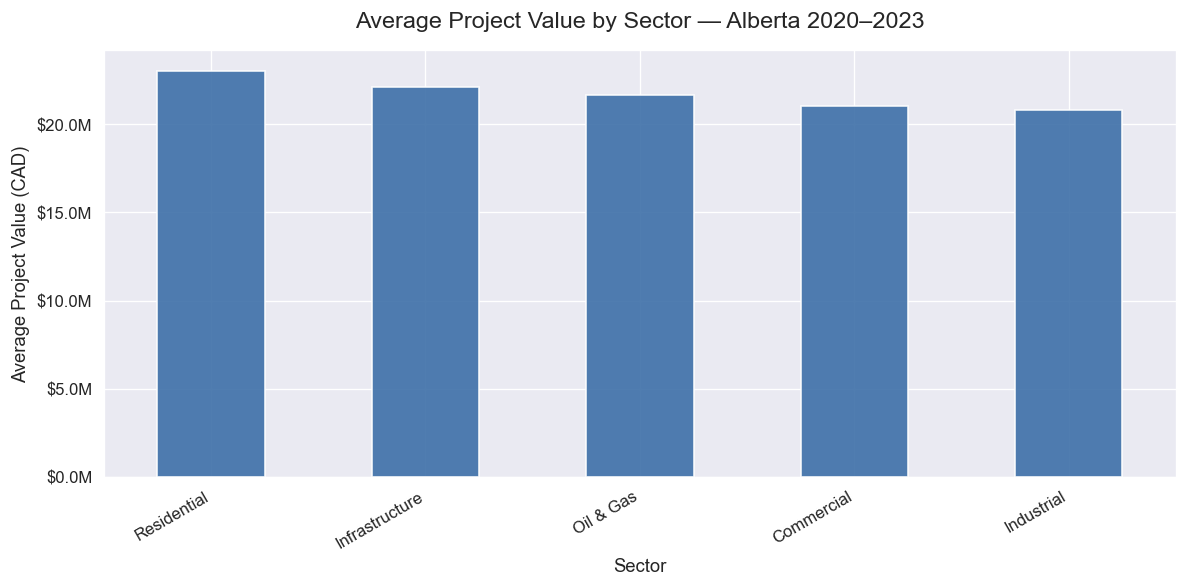

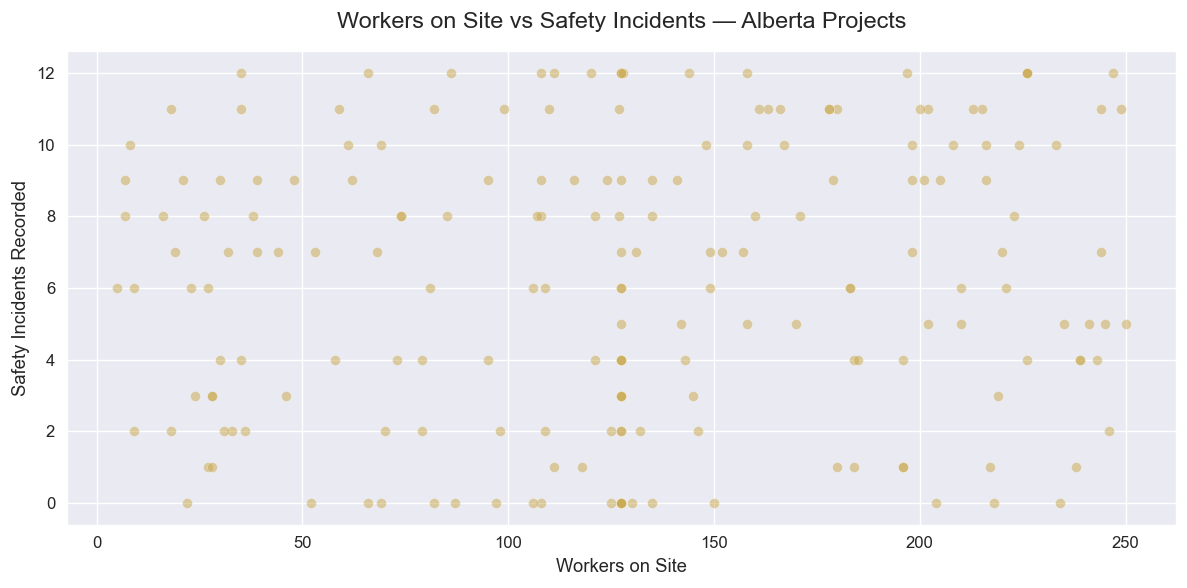

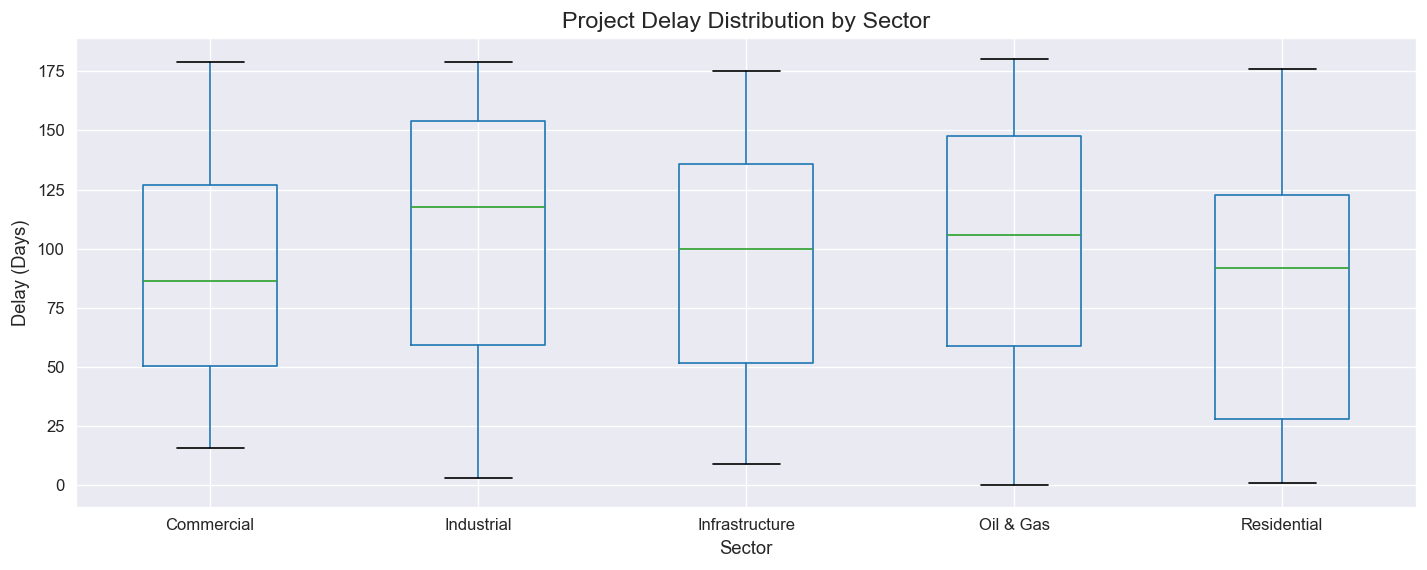

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
 
os.makedirs("charts", exist_ok=True)
 
sns.set_style("darkgrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 5)
 
# --- Chart 1: Distribution of Project Values ---
fig, ax = plt.subplots()
ax.hist(df["project_value_cad"], bins=30, color="steelblue", edgecolor="white", alpha=0.85)
ax.set_title("Distribution of Alberta Construction Project Values", fontsize=14, pad=14)
ax.set_xlabel("Project Value (CAD)", fontsize=11)
ax.set_ylabel("Number of Projects", fontsize=11)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.0f}M"))
plt.tight_layout()
plt.savefig("charts/chart_01_project_value_distribution.png", dpi=150)
plt.show()
 
# --- Chart 2: Average Project Value by Sector ---
sector_avg = df.groupby("sector")["project_value_cad"].mean().sort_values(ascending=False)
fig, ax = plt.subplots()
sector_avg.plot(kind="bar", ax=ax, color="#3d6fa8", edgecolor="white", alpha=0.9)
ax.set_title("Average Project Value by Sector — Alberta 2020–2023", fontsize=14, pad=14)
ax.set_xlabel("Sector", fontsize=11)
ax.set_ylabel("Average Project Value (CAD)", fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"${y/1e6:.1f}M"))
plt.tight_layout()
plt.savefig("charts/chart_02_value_by_sector.png", dpi=150)
plt.show()
 
# --- Chart 3: Workers on Site vs Safety Incidents ---
fig, ax = plt.subplots()
ax.scatter(
    df["workers_on_site"],
    df["safety_incidents"],
    alpha=0.5,
    color="#c9a84c",
    edgecolors="white",
    linewidth=0.3
)
ax.set_title("Workers on Site vs Safety Incidents — Alberta Projects", fontsize=14, pad=14)
ax.set_xlabel("Workers on Site", fontsize=11)
ax.set_ylabel("Safety Incidents Recorded", fontsize=11)
plt.tight_layout()
plt.savefig("charts/chart_03_workers_vs_incidents.png", dpi=150)
plt.show()
 
# --- Chart 4: Project Delay by Sector ---
fig, ax = plt.subplots(figsize=(12, 5))
df.boxplot(column="delay_days", by="sector", ax=ax, grid=True)
ax.set_title("Project Delay Distribution by Sector", fontsize=14)
ax.set_xlabel("Sector", fontsize=11)
ax.set_ylabel("Delay (Days)", fontsize=11)
plt.suptitle("")
plt.tight_layout()
plt.savefig("charts/chart_04_delays_by_sector.png", dpi=150)
plt.show()
